# **Plotting Test Metrics for Cell Type Classification**
---

This notebook evaluates and visualizes the performance of cell type classifier on the held-out test set (P7 donor). It loads prediction outputs from Geneformer and computes standard and L1-aware metrics, and generates confusion matrices.

## What Does This Notebook Do?

1. **Load reference data**: Reads the preprocessed `.h5ad` file to extract cell type hierarchy 
2. **Compute standard metrics**: Calculates accuracy, macro F1, and per-class classification reports
3. **Compute L1-aware metrics**: Evaluates predictions accounting for the L1 group hierarchy — a prediction is "correct at L1" if it falls within the true L1 group
4. **Plot confusion matrices**: Generates L3 confusion matrices with optional boundary normalization and L1 group separator annotations

## Models Evaluated

- **Geneformer**: Loads predictions from `.pkl` files produced by the Geneformer fine-tuning pipeline (notebooks 04 → fine-tuning → evaluation)

## Cell Type Hierarchy

Evaluation uses two levels of cell type annotations:
- **L3** (fine-grained): Primary classification target
- **L1** (coarse): Used for L1-aware metrics — predictions within the correct L1 group are considered partially correct

## Importance of Donor-Level Test Split

- **P7 cells remain in test set**: No data leakage from training
- **Evaluation on unseen donor**: Model is tested on a completely held-out donor
- **Split labels preserved**: From h5ad → tokenization → classifier → evaluation

---

# __Plotting Test Metrics from `predictions` of Geneneformer__

## Setup Instructions

Before running this notebook, update the paths in the configuration cell below:
- `BASE_DIR`: Root directory for the benchmarking repository
- `DATA_PATH`: Path to the preprocessed `.h5ad` file with cell type and split information (from notebook 02)
- `VERSION`: Geneformer model version (`v1` or `v2`)
- `MODEL_SIZE`: Geneformer model size (e.g. `10m`, `106m`, `316m`)
- `LEVEL`: Cell type annotation level (e.g. `l3`)
- `PRED_DICT_PATH`: Path to Geneformer prediction pickle (`.pkl`) produced by the fine-tuning pipeline
- `CLASS_DICT_PATH`: Path to Geneformer class ID dictionary pickle (`.pkl`)

In [ ]:
from pathlib import Path

# ===== CONFIGURATION - Update these paths for your environment =====
BASE_DIR = Path("/scratch/tmurugan/geneformer_benchmarking")

# Preprocessed h5ad file with cell type and split information (from notebook 02)
DATA_PATH = BASE_DIR / "data/preprocessed_data/p7_test_donor_split/citeseq_pbmc_with_p7_l3_split.h5ad"

# Geneformer model identifiers
VERSION = "v1"      # "v1" or "v2"
MODEL_SIZE = "10m"  # e.g. "10m", "104m", "316m"
LEVEL = "l3"        # cell type annotation level

# Geneformer evaluation paths
OUTPUT_DIR = BASE_DIR / "data" / "output" / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_citeseq_pbmc_cellclassification"
PRED_DICT_PATH = OUTPUT_DIR / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_pred_dict.pkl"
CLASS_DICT_PATH = BASE_DIR / "data" / "classifier" / f"{VERSION}_{LEVEL}_citeseq_classifier_dir" / "citeseq_pbmc_cellclassification_id_class_dict.pkl"
TEST_EVAL_PATH = OUTPUT_DIR / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_test_metrics_dict.pkl"

print(f"Configuration loaded:")
print(f"Base directory: {BASE_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Geneformer prediction dict: {PRED_DICT_PATH}")
print(f"Geneformer class dict: {CLASS_DICT_PATH}")
print(f"Geneformer test evaluation metrics: {TEST_EVAL_PATH}")

Configuration loaded:
Base directory: /scratch/tmurugan/geneformer_benchmarking
Data path: /scratch/tmurugan/geneformer_benchmarking/data/preprocessed_data/p7_test_donor_split/citeseq_pbmc_with_p7_l3_split.h5ad
Geneformer prediction dict: /scratch/tmurugan/geneformer_benchmarking/data/output/v1_10m_l3_test_eval_citeseq_pbmc_cellclassification/v1_10m_l3_test_eval_pred_dict.pkl
Geneformer class dict: /scratch/tmurugan/geneformer_benchmarking/data/classifier/v1_l3_citeseq_classifier_dir/citeseq_pbmc_cellclassification_id_class_dict.pkl
Geneformer test evaluation metrics: /scratch/tmurugan/geneformer_benchmarking/data/output/v1_10m_l3_test_eval_citeseq_pbmc_cellclassification/v1_10m_l3_test_eval_test_metrics_dict.pkl


## Load Raw Data

In [2]:
# Import libraries
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import scanpy as sc

# Load the anndata file
adata = sc.read_h5ad(DATA_PATH)
print(adata)

AnnData object with n_obs × n_vars = 161764 × 20264
    obs: 'nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor_id', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'cell_type_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'joinid', 'l3_split'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensembl_id'
    uns: 'celltype.l3_colors', 'citation', 'default_embedding', 'neighbors', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_apca', 'X_aumap', 

## Prepare labels for evaluation (optional)

In [3]:
# Check the unique cell types in the dataset and sort them
l1_sort = sorted(adata.obs['celltype.l1'].unique())
print("l1 cell types:", l1_sort)

l1 cell types: ['B', 'CD4 T', 'CD8 T', 'DC', 'Mono', 'NK', 'other', 'other T']


In [4]:
# Create a dictionary which maps unique l3 to l1 cell types
l3_to_l1 =adata.obs[['celltype.l3', 'celltype.l1']].drop_duplicates().set_index('celltype.l3')['celltype.l1'].to_dict()
print(l3_to_l1)

{'CD14 Mono': 'Mono', 'CD4 TCM_1': 'CD4 T', 'CD8 Naive': 'CD8 T', 'NK_2': 'NK', 'CD8 TEM_1': 'CD8 T', 'CD16 Mono': 'Mono', 'B intermediate lambda': 'B', 'CD4 Naive': 'CD4 T', 'CD4 CTL': 'CD4 T', 'B naive kappa': 'B', 'CD4 TCM_3': 'CD4 T', 'MAIT': 'other T', 'CD4 TCM_2': 'CD4 T', 'CD8 TEM_2': 'CD8 T', 'gdT_3': 'other T', 'NK_1': 'NK', 'CD8 TCM_1': 'CD8 T', 'dnT_2': 'other T', 'B intermediate kappa': 'B', 'B memory kappa': 'B', 'Doublet': 'other', 'pDC': 'DC', 'CD8 TEM_5': 'CD8 T', 'gdT_1': 'other T', 'B naive lambda': 'B', 'NK_4': 'NK', 'CD8 Proliferating': 'CD8 T', 'CD8 TCM_2': 'CD8 T', 'Treg Naive': 'CD4 T', 'Plasma': 'B', 'CD4 TEM_1': 'CD4 T', 'Treg Memory': 'CD4 T', 'CD4 TEM_3': 'CD4 T', 'CD8 TCM_3': 'CD8 T', 'cDC2_1': 'DC', 'NK Proliferating': 'NK', 'CD8 TEM_4': 'CD8 T', 'ASDC_pDC': 'DC', 'CD4 TEM_2': 'CD4 T', 'B memory lambda': 'B', 'dnT_1': 'other T', 'HSPC': 'other', 'cDC2_2': 'DC', 'Platelet': 'other', 'NK_CD56bright': 'NK', 'CD4 TEM_4': 'CD4 T', 'CD8 TEM_6': 'CD8 T', 'CD8 Naiv

In [5]:
# Sort l3 cell types based on l1 group order (l1_sort), then alphabetically within each group
l3_sort = sorted(adata.obs['celltype.l3'].unique(), key=lambda x: (l1_sort.index(l3_to_l1.get(x, '')), x))
print(l3_sort)

['B intermediate kappa', 'B intermediate lambda', 'B memory kappa', 'B memory lambda', 'B naive kappa', 'B naive lambda', 'Plasma', 'Plasmablast', 'CD4 CTL', 'CD4 Naive', 'CD4 Proliferating', 'CD4 TCM_1', 'CD4 TCM_2', 'CD4 TCM_3', 'CD4 TEM_1', 'CD4 TEM_2', 'CD4 TEM_3', 'CD4 TEM_4', 'Treg Memory', 'Treg Naive', 'CD8 Naive', 'CD8 Naive_2', 'CD8 Proliferating', 'CD8 TCM_1', 'CD8 TCM_2', 'CD8 TCM_3', 'CD8 TEM_1', 'CD8 TEM_2', 'CD8 TEM_3', 'CD8 TEM_4', 'CD8 TEM_5', 'CD8 TEM_6', 'ASDC_mDC', 'ASDC_pDC', 'cDC1', 'cDC2_1', 'cDC2_2', 'pDC', 'CD14 Mono', 'CD16 Mono', 'NK Proliferating', 'NK_1', 'NK_2', 'NK_3', 'NK_4', 'NK_CD56bright', 'Doublet', 'Eryth', 'HSPC', 'ILC', 'Platelet', 'MAIT', 'dnT_1', 'dnT_2', 'gdT_1', 'gdT_2', 'gdT_3', 'gdT_4']


## Evaluation Test Metrics and Confusion Matrix plot

### For V1-10M

In [ ]:
####################################################
#  Citeseq PBMC L3 Test Metrics - Geneformer-V1-10M
####################################################

# Load pickle
pred1 = pickle.load(open(PRED_DICT_PATH, "rb"))
idmap1 = pickle.load(open(CLASS_DICT_PATH, "rb"))

# sort cell type labels in idmap1 according to cell type l3
name_to_id1 = {v:k for k,v in idmap1.items()} # reverse the idmap to get cell type labels as keys and indices as values
ordered_ids1 = [name_to_id1[x] for x in l3_sort] # contains list of cell type indices in the order corresponding to l3_sort (which is sorted by l1 groups and then alphabetically)

# citeseq pbmc l3 classification test metrics
y_pred1 = pred1["pred_ids"]
y_true1 = pred1["label_ids"]
labels1 = [idmap1[i] for i in ordered_ids1] # contains list of cell type labels in the order corresponding to l3_sort
cm1 = confusion_matrix(y_true1, y_pred1, labels=ordered_ids1) # ordered_ids1 is used to specify the labels so that they are in the same label space as the cell type indices in y_true1 and y_pred1
cm_df1 = pd.DataFrame(cm1, index=labels1, columns=labels1) # index (rows are true labels) and columns (predicted labels) are both set to labels1

print("Accuracy:", accuracy_score(y_true1,y_pred1))
print("Macro F1:", f1_score(y_true1,y_pred1,average="macro"))
print(classification_report(y_true1,y_pred1,labels=ordered_ids1,target_names=labels1))


Accuracy: 0.8535812299485911
Macro F1: 0.642554339973245
                       precision    recall  f1-score   support

 B intermediate kappa       0.35      0.15      0.21       253
B intermediate lambda       0.55      0.52      0.53       414
       B memory kappa       0.51      0.92      0.65       632
      B memory lambda       0.00      0.00      0.00       377
        B naive kappa       0.58      0.94      0.72      1013
       B naive lambda       0.74      0.10      0.17       680
               Plasma       0.96      0.99      0.97        91
          Plasmablast       1.00      0.58      0.74        12
              CD4 CTL       0.96      0.95      0.96       514
            CD4 Naive       0.94      0.97      0.96      2441
    CD4 Proliferating       0.67      0.82      0.73        22
            CD4 TCM_1       0.84      0.79      0.81       979
            CD4 TCM_2       0.85      0.57      0.68       126
            CD4 TCM_3       0.67      0.90      0.77       6

/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [7]:
# Print confusion matrix
print ("Confusion Matrix:\n", cm_df1)

Confusion Matrix:
                        B intermediate kappa  B intermediate lambda  \
B intermediate kappa                     37                    107   
B intermediate lambda                    34                    215   
B memory kappa                           17                     23   
B memory lambda                          13                     11   
B naive kappa                             5                     27   
B naive lambda                            1                      8   
Plasma                                    0                      0   
Plasmablast                               0                      0   
CD4 CTL                                   0                      0   
CD4 Naive                                 0                      0   
CD4 Proliferating                         0                      0   
CD4 TCM_1                                 0                      0   
CD4 TCM_2                                 0                      0   
C

In [8]:
###############################################################
# Compute metrics with L1-aware evaluation - Geneformer-V1-10M
###############################################################

# Create a DataFrame from Geneformer predictions for easier manipulation
geneformer_pred_df = pd.DataFrame({
    'true_label': [labels1[ordered_ids1.index(tid)] for tid in y_true1],
    'predicted_label': [labels1[ordered_ids1.index(pid)] for pid in y_pred1]
})

# Map each prediction to its L1 group
geneformer_pred_df['true_l1'] = geneformer_pred_df['true_label'].map(l3_to_l1)
geneformer_pred_df['pred_l1'] = geneformer_pred_df['predicted_label'].map(l3_to_l1)

# Create L1-aware predictions: consider correct if predicted L3 is in correct L1 group
geneformer_pred_df['l1_match'] = geneformer_pred_df['true_l1'] == geneformer_pred_df['pred_l1']

# Compute per-class F1 scores where "correct" means L1 group matches
print(f"\n=== Per-class F1 scores (L1-group aware) - Geneformer-{VERSION.upper()}-{MODEL_SIZE.upper()} ===")
print("Only counting predictions where L1 group is correct\n")

per_class_f1_l1_gf = {}
for label in labels1:
    # L1 group of this L3 label
    label_l1 = l3_to_l1[label]
    
    # Samples where true L3 == label
    true_mask = geneformer_pred_df['true_label'] == label
    label_samples = geneformer_pred_df[true_mask]
    
    if len(label_samples) == 0:
        continue
    
    # True Positives:
    # True L3 = label AND predicted L1 matches label's L1
    tp = (label_samples['pred_l1'] == label_l1).sum()
    
    # False Negatives:
    # True L3 = label BUT predicted L1 is different
    fn = (label_samples['pred_l1'] != label_l1).sum()
    
    # False Positives:
    # Predicted L1 matches label's L1
    # BUT true L1 is different
    fp = (
        (geneformer_pred_df['pred_l1'] == label_l1) &
        (geneformer_pred_df['true_l1'] != label_l1)
    ).sum()
    
    # Precision / Recall / F1
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    per_class_f1_l1_gf[label] = {
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'support': len(label_samples)
    }
    
    print(f"{label:25s} - F1: {f1:.3f}  "
          f"(TP: {tp:4d}, FP: {fp:4d}, FN: {fn:4d}, Support: {len(label_samples):4d})")

# Compute L1-aware Macro F1 (average of all per-class F1 scores)
l1_macro_f1_gf = np.mean([v['f1'] for v in per_class_f1_l1_gf.values()])

# Compute L1-aware accuracy (proportion of predictions in correct L1 group)
l1_accuracy_gf = geneformer_pred_df['l1_match'].mean()

print(f"\n{'='*80}")
print(f"L1-aware Accuracy (predictions in correct L1 group): {l1_accuracy_gf:.4f}")
print(f"L1-aware Macro F1: {l1_macro_f1_gf:.4f}")
print(f"{'='*80}")


=== Per-class F1 scores (L1-group aware) - Geneformer-V1-10M ===
Only counting predictions where L1 group is correct

B intermediate kappa      - F1: 0.998  (TP:  253, FP:    1, FN:    0, Support:  253)
B intermediate lambda     - F1: 0.998  (TP:  413, FP:    1, FN:    1, Support:  414)
B memory kappa            - F1: 0.998  (TP:  631, FP:    1, FN:    1, Support:  632)
B memory lambda           - F1: 0.999  (TP:  377, FP:    1, FN:    0, Support:  377)
B naive kappa             - F1: 1.000  (TP: 1013, FP:    1, FN:    0, Support: 1013)
B naive lambda            - F1: 0.998  (TP:  678, FP:    1, FN:    2, Support:  680)
Plasma                    - F1: 0.995  (TP:   91, FP:    1, FN:    0, Support:   91)
Plasmablast               - F1: 0.917  (TP:   11, FP:    1, FN:    1, Support:   12)
CD4 CTL                   - F1: 0.864  (TP:  491, FP:  131, FN:   23, Support:  514)
CD4 Naive                 - F1: 0.967  (TP: 2407, FP:  131, FN:   34, Support: 2441)
CD4 Proliferating         - F1:

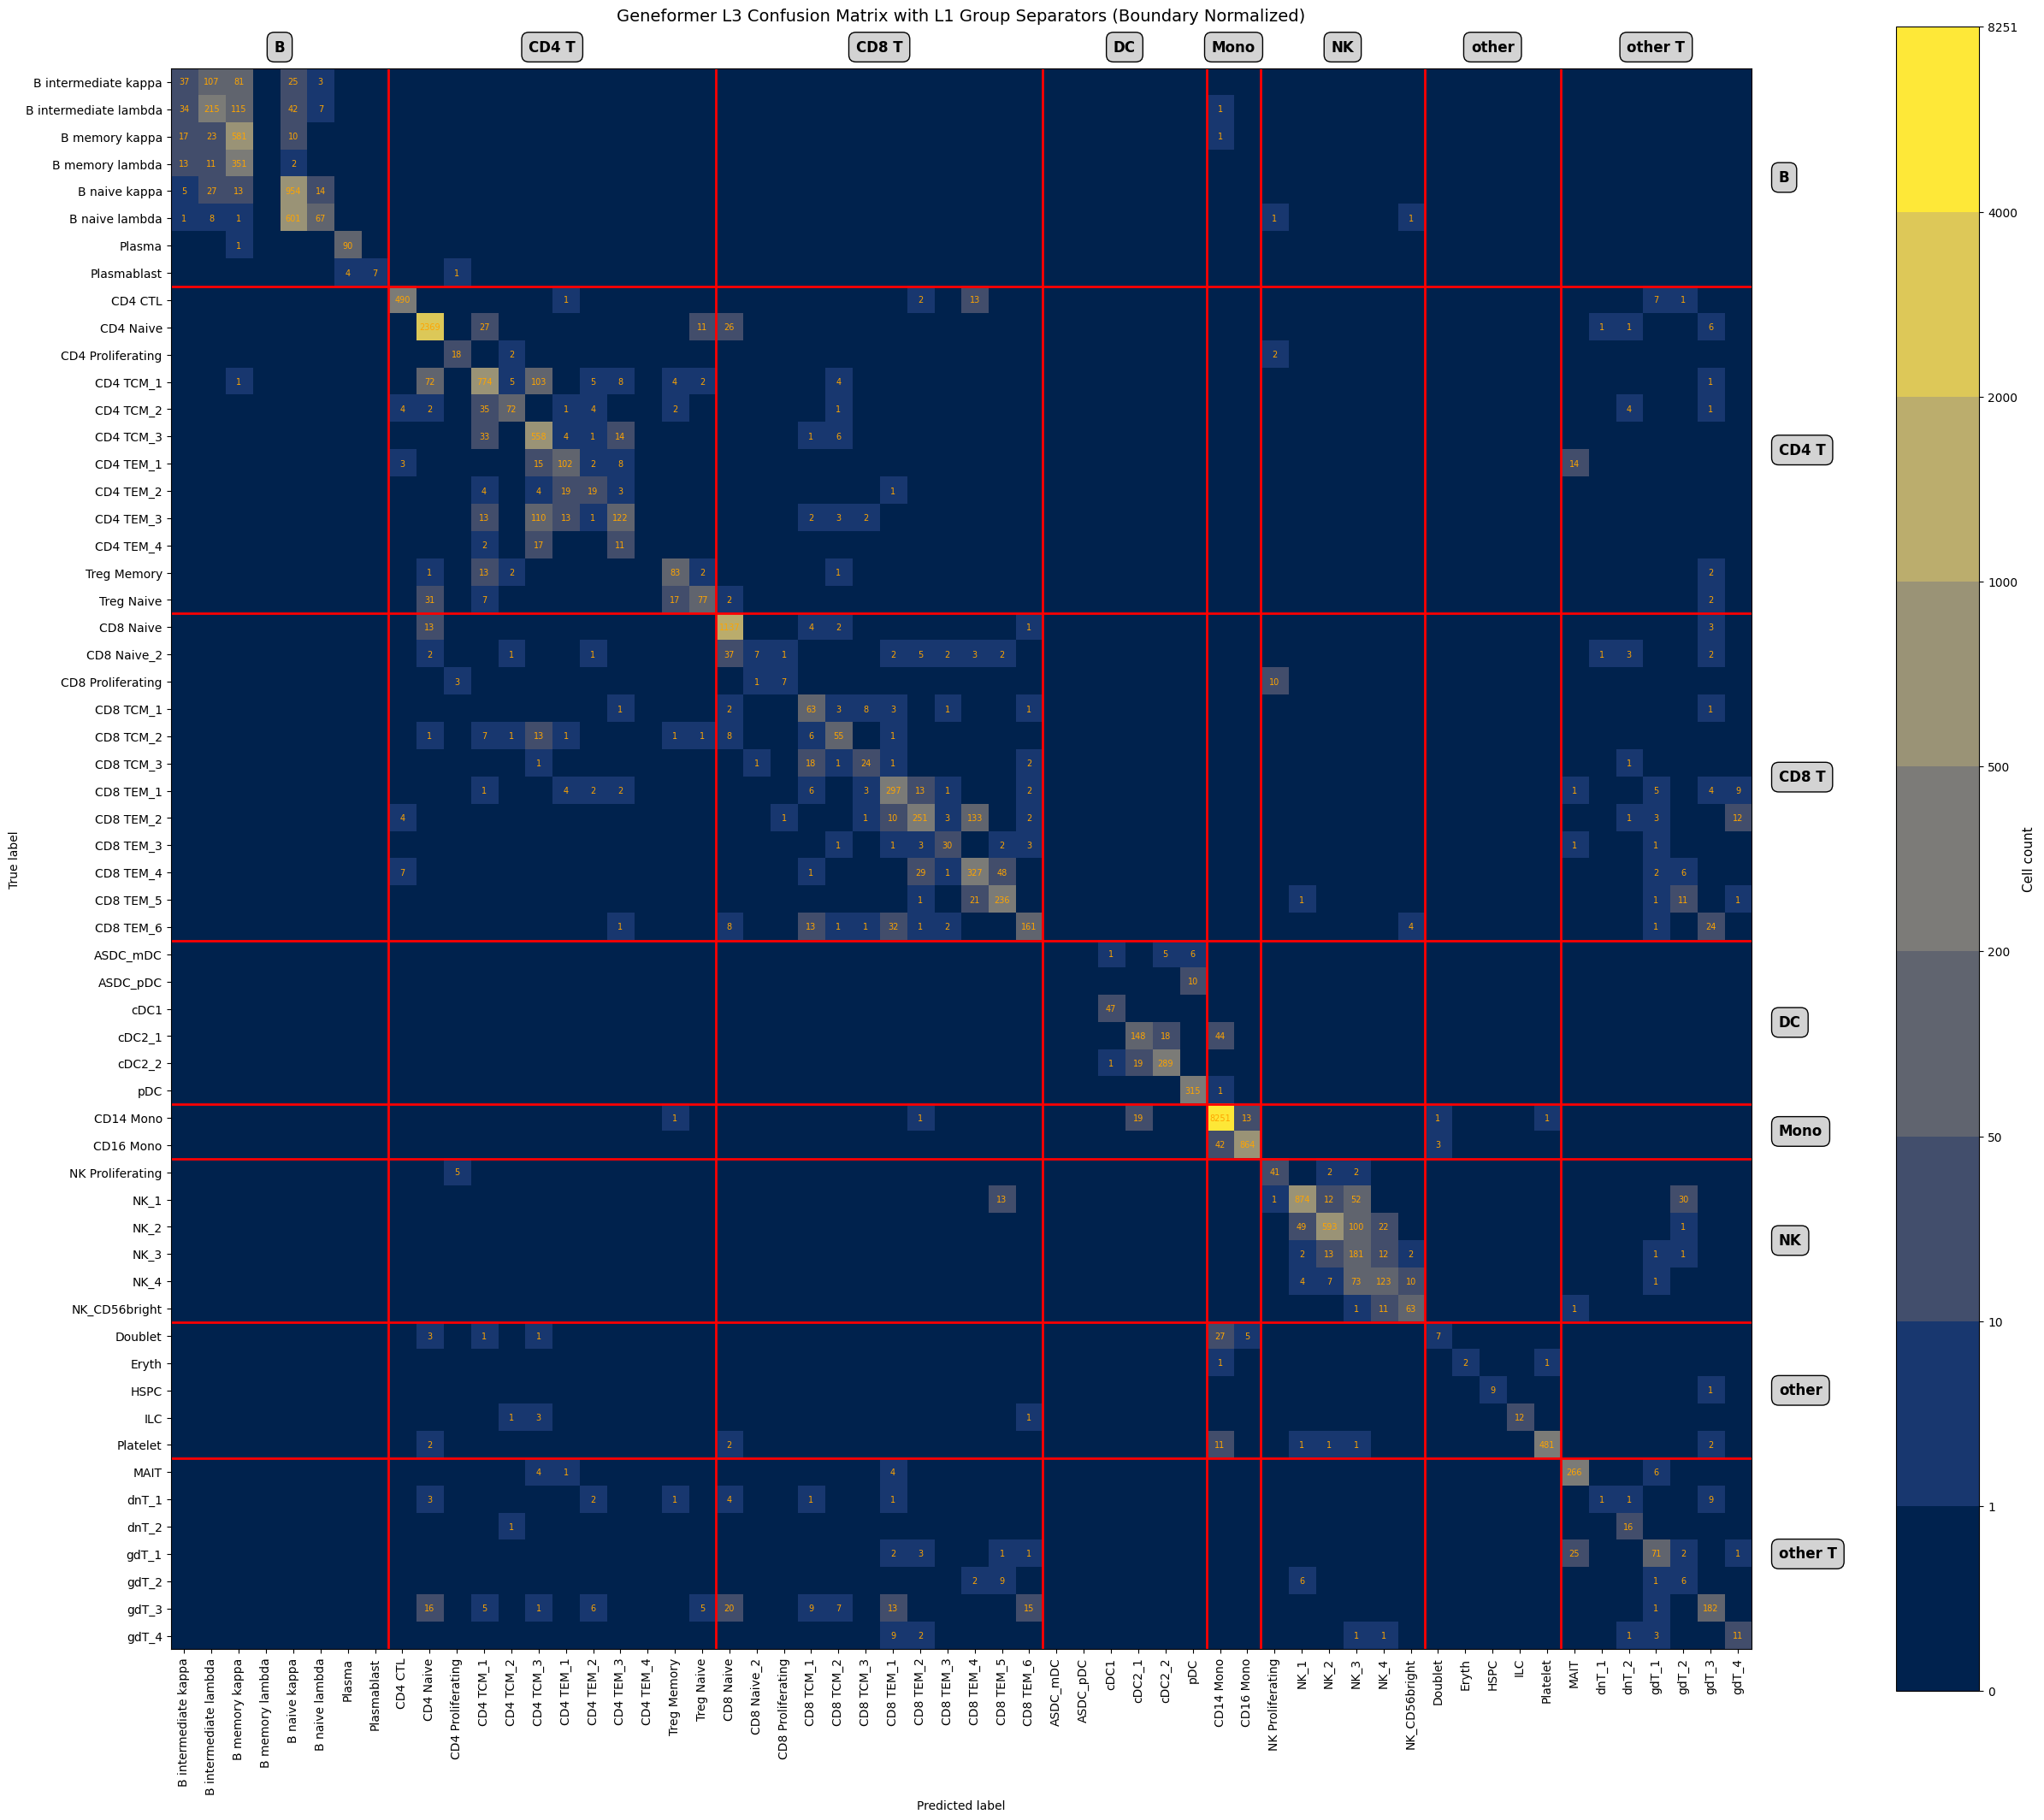

In [9]:
####################################################################################################
# Plot L3 Confusion Matrix with Boundary Normalization and L1 Group Annotations - Geneformer-V1-10M
####################################################################################################

from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.colors import BoundaryNorm

# Define boundaries appropriate for L3 dataset  
bounds = [0, 1, 10, 50, 200, 500, 1000, 2000, 4000, cm_df1.values.max()]
norm = BoundaryNorm(bounds, ncolors=256, clip=True)

fig, ax = plt.subplots(figsize=(24, 24))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_df1.values,
    display_labels=labels1
)
disp.plot(
    ax=ax,
    cmap="cividis",
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

# Apply normalization after plotting
im = disp.im_
im.set_norm(norm)

# Increase font size and hide zero-value annotations
for value, text in zip(cm_df1.values.ravel(), disp.text_.ravel()):
    if value == 0:
        text.set_text("")
        continue
    text.set_fontsize(7)
    text.set_color('orange')

# Add separators and L1 group annotations
l1_groups = []
current_l1 = None
start_idx = 0

for idx, l3 in enumerate(labels1):
    l1 = l3_to_l1.get(l3, 'Unknown')
    if l1 != current_l1:
        if current_l1 is not None:
            l1_groups.append((current_l1, start_idx, idx))
            # Draw separator line
            ax.axhline(y=idx - 0.5, color='red', linewidth=2)
            ax.axvline(x=idx - 0.5, color='red', linewidth=2)
        current_l1 = l1
        start_idx = idx

# Add the last group
if current_l1 is not None:
    l1_groups.append((current_l1, start_idx, len(labels1)))

# Add L1 group labels on the right side
for l1_name, start, end in l1_groups:
    mid_point = (start + end) / 2 - 0.5
    ax.text(len(labels1) + 0.5, mid_point, l1_name, 
            ha='left', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', edgecolor='black'))

# Add L1 group labels on the top (moved higher up and rotated)
for l1_name, start, end in l1_groups:
    mid_point = (start + end) / 2 - 0.5
    ax.text(mid_point, -1.0, l1_name, 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            rotation=0,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', edgecolor='black'))

# Add custom colorbar
cbar = fig.colorbar(im, ax=ax, ticks=bounds, fraction=0.046, pad=0.08)
cbar.ax.set_ylabel("Cell count", rotation=90, fontsize=11)

ax.set_title("Geneformer L3 Confusion Matrix with L1 Group Separators (Boundary Normalized)", fontsize=14, pad=40)
plt.tight_layout()
plt.show()

### For V2-104M

In [ ]:
####################################################
#  Citeseq PBMC L3 Test Metrics - Geneformer-V2-104M
####################################################

# Geneformer model identifiers
VERSION = "v2"      # "v1" or "v2"
MODEL_SIZE = "104m"  # e.g. "10m", "104m", "316m"
LEVEL = "l3"        # cell type annotation level

# Geneformer evaluation paths
OUTPUT_DIR = BASE_DIR / "data" / "output" / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_citeseq_pbmc_cellclassification"
PRED_DICT_PATH = OUTPUT_DIR / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_pred_dict.pkl"
CLASS_DICT_PATH = BASE_DIR / "data" / "classifier" / f"{VERSION}_{LEVEL}_citeseq_classifier_dir" / "citeseq_pbmc_cellclassification_id_class_dict.pkl"
TEST_EVAL_PATH = OUTPUT_DIR / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_test_metrics_dict.pkl"

print(f"Configuration loaded:")
print(f"Base directory: {BASE_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Geneformer prediction dict: {PRED_DICT_PATH}")
print(f"Geneformer class dict: {CLASS_DICT_PATH}")
print(f"Geneformer test evaluation metrics: {TEST_EVAL_PATH}")

Configuration loaded:
Base directory: /scratch/tmurugan/geneformer_benchmarking
Data path: /scratch/tmurugan/geneformer_benchmarking/data/preprocessed_data/p7_test_donor_split/citeseq_pbmc_with_p7_l3_split.h5ad
Geneformer prediction dict: /scratch/tmurugan/geneformer_benchmarking/data/output/v2_104m_l3_test_eval_citeseq_pbmc_cellclassification/v2_104m_l3_test_eval_pred_dict.pkl
Geneformer class dict: /scratch/tmurugan/geneformer_benchmarking/data/classifier/v2_l3_citeseq_classifier_dir/citeseq_pbmc_cellclassification_id_class_dict.pkl
Geneformer test evaluation metrics: /scratch/tmurugan/geneformer_benchmarking/data/output/v2_104m_l3_test_eval_citeseq_pbmc_cellclassification/v2_104m_l3_test_eval_test_metrics_dict.pkl


In [14]:
####################################################
#  Citeseq PBMC L3 Test Metrics - Geneformer-V1-10M
####################################################

# Load pickle
pred2 = pickle.load(open(PRED_DICT_PATH, "rb"))
idmap2 = pickle.load(open(CLASS_DICT_PATH, "rb"))

# sort cell type labels in idmap2 according to cell type l3
name_to_id2 = {v:k for k,v in idmap2.items()} # reverse the idmap to get cell type labels as keys and indices as values
ordered_ids2 = [name_to_id2[x] for x in l3_sort] # contains list of cell type indices in the order corresponding to l3_sort (which is sorted by l1 groups and then alphabetically)

# citeseq pbmc l3 classification test metrics
y_pred2 = pred2["pred_ids"]
y_true2 = pred2["label_ids"]
labels2 = [idmap2[i] for i in ordered_ids2] # contains list of cell type labels in the order corresponding to l3_sort
cm2 = confusion_matrix(y_true2, y_pred2, labels=ordered_ids2) # ordered_ids2 is used to specify the labels so that they are in the same label space as the cell type indices in y_true2 and y_pred2
cm_df2 = pd.DataFrame(cm2, index=labels2, columns=labels2) #index (rows are true labels) and columns (predicted labels) are both set to labels2

print("Accuracy:", accuracy_score(y_true2,y_pred2))
print("Macro F1:", f1_score(y_true2,y_pred2,average="macro"))
print(classification_report(y_true2,y_pred2,labels=ordered_ids2,target_names=labels2))


Accuracy: 0.8818368056897685
Macro F1: 0.7510330366081145
                       precision    recall  f1-score   support

 B intermediate kappa       0.48      0.40      0.44       253
B intermediate lambda       0.56      0.68      0.61       414
       B memory kappa       0.58      0.92      0.71       632
      B memory lambda       0.00      0.00      0.00       377
        B naive kappa       0.68      0.73      0.70      1013
       B naive lambda       0.58      0.47      0.52       680
               Plasma       1.00      0.98      0.99        91
          Plasmablast       0.92      0.92      0.92        12
              CD4 CTL       0.99      0.94      0.96       514
            CD4 Naive       0.96      0.98      0.97      2441
    CD4 Proliferating       0.68      0.95      0.79        22
            CD4 TCM_1       0.86      0.83      0.84       979
            CD4 TCM_2       0.69      0.81      0.75       126
            CD4 TCM_3       0.83      0.85      0.84       

/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [15]:
# Print confusion matrix
print ("Confusion Matrix:\n", cm_df2)

Confusion Matrix:
                        B intermediate kappa  B intermediate lambda  \
B intermediate kappa                    102                    112   
B intermediate lambda                    79                    281   
B memory kappa                           15                     32   
B memory lambda                           3                     29   
B naive kappa                             5                     30   
B naive lambda                            6                     18   
Plasma                                    0                      0   
Plasmablast                               0                      0   
CD4 CTL                                   0                      0   
CD4 Naive                                 0                      0   
CD4 Proliferating                         0                      0   
CD4 TCM_1                                 0                      0   
CD4 TCM_2                                 0                      0   
C

In [16]:
###############################################################
# Compute metrics with L1-aware evaluation - Geneformer-V1-10M
###############################################################

# Create a DataFrame from Geneformer predictions for easier manipulation
geneformer_pred_df2 = pd.DataFrame({
    'true_label': [labels2[ordered_ids2.index(tid)] for tid in y_true2],
    'predicted_label': [labels2[ordered_ids2.index(pid)] for pid in y_pred2]
})

# Map each prediction to its L1 group
geneformer_pred_df2['true_l1'] = geneformer_pred_df2['true_label'].map(l3_to_l1)
geneformer_pred_df2['pred_l1'] = geneformer_pred_df2['predicted_label'].map(l3_to_l1)

# Create L1-aware predictions: consider correct if predicted L3 is in correct L1 group
geneformer_pred_df2['l1_match'] = geneformer_pred_df2['true_l1'] == geneformer_pred_df2['pred_l1']

# Compute per-class F1 scores where "correct" means L1 group matches
print(f"\n=== Per-class F1 scores (L1-group aware) - Geneformer-{VERSION.upper()}-{MODEL_SIZE.upper()} ===")
print("Only counting predictions where L1 group is correct\n")

per_class_f1_l1_gf2 = {}
for label in labels2:
    # L1 group of this L3 label
    label_l1 = l3_to_l1[label]
    
    # Samples where true L3 == label
    true_mask = geneformer_pred_df2['true_label'] == label
    label_samples = geneformer_pred_df2[true_mask]
    
    if len(label_samples) == 0:
        continue
    
    # True Positives:
    # True L3 = label AND predicted L1 matches label's L1
    tp = (label_samples['pred_l1'] == label_l1).sum()
    
    # False Negatives:
    # True L3 = label BUT predicted L1 is different
    fn = (label_samples['pred_l1'] != label_l1).sum()
    
    # False Positives:
    # Predicted L1 matches label's L1
    # BUT true L1 is different
    fp = (
        (geneformer_pred_df2['pred_l1'] == label_l1) &
        (geneformer_pred_df2['true_l1'] != label_l1)
    ).sum()
    
    # Precision / Recall / F1
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    per_class_f1_l1_gf2[label] = {
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'support': len(label_samples)
    }
    
    print(f"{label:25s} - F1: {f1:.3f}  "
          f"(TP: {tp:4d}, FP: {fp:4d}, FN: {fn:4d}, Support: {len(label_samples):4d})")

# Compute L1-aware Macro F1 (average of all per-class F1 scores)
l1_macro_f1_gf2 = np.mean([v['f1'] for v in per_class_f1_l1_gf2.values()])

# Compute L1-aware accuracy (proportion of predictions in correct L1 group)
l1_accuracy_gf2 = geneformer_pred_df2['l1_match'].mean()

print(f"\n{'='*80}")
print(f"L1-aware Accuracy (predictions in correct L1 group): {l1_accuracy_gf2:.4f}")
print(f"L1-aware Macro F1: {l1_macro_f1_gf2:.4f}")
print(f"{'='*80}")


=== Per-class F1 scores (L1-group aware) - Geneformer-V2-104M ===
Only counting predictions where L1 group is correct

B intermediate kappa      - F1: 0.996  (TP:  253, FP:    2, FN:    0, Support:  253)
B intermediate lambda     - F1: 0.996  (TP:  413, FP:    2, FN:    1, Support:  414)
B memory kappa            - F1: 0.998  (TP:  631, FP:    2, FN:    1, Support:  632)
B memory lambda           - F1: 0.997  (TP:  377, FP:    2, FN:    0, Support:  377)
B naive kappa             - F1: 0.999  (TP: 1013, FP:    2, FN:    0, Support: 1013)
B naive lambda            - F1: 0.998  (TP:  679, FP:    2, FN:    1, Support:  680)
Plasma                    - F1: 0.989  (TP:   91, FP:    2, FN:    0, Support:   91)
Plasmablast               - F1: 0.880  (TP:   11, FP:    2, FN:    1, Support:   12)
CD4 CTL                   - F1: 0.938  (TP:  489, FP:   40, FN:   25, Support:  514)
CD4 Naive                 - F1: 0.989  (TP: 2426, FP:   40, FN:   15, Support: 2441)
CD4 Proliferating         - F1

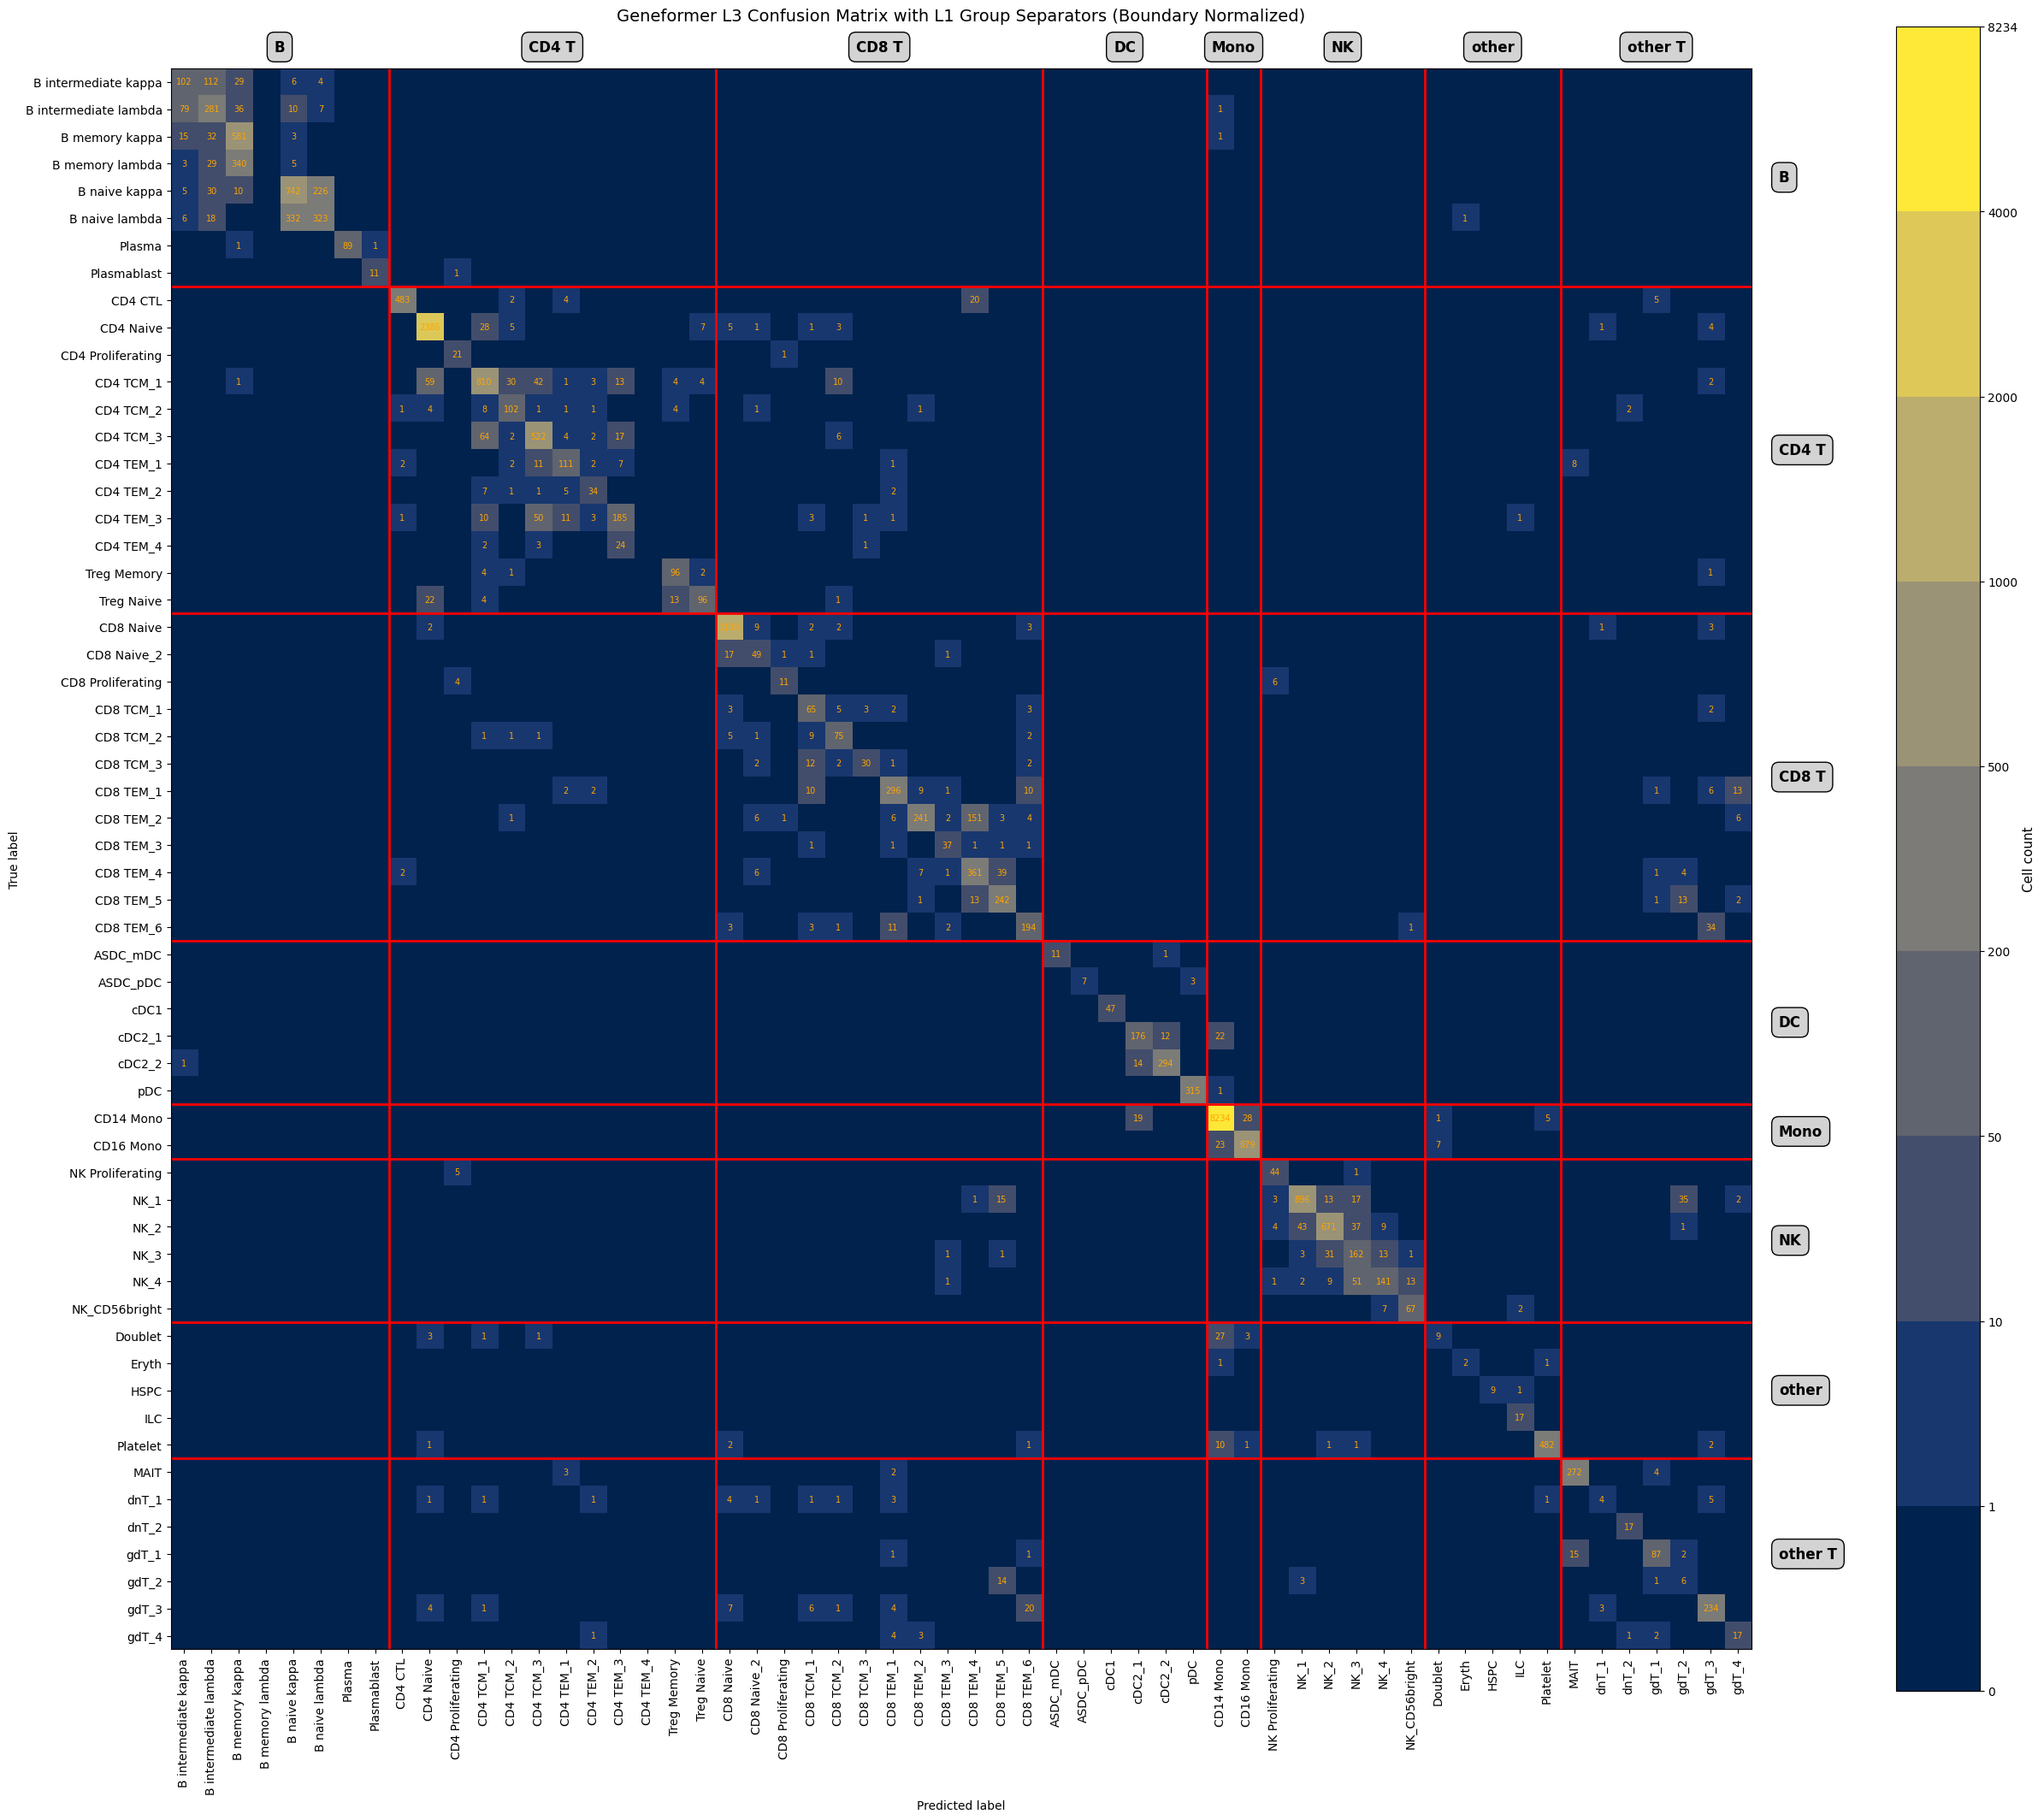

In [17]:
####################################################################################################
# Plot L3 Confusion Matrix with Boundary Normalization and L1 Group Annotations - Geneformer-V2-104M
####################################################################################################

from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.colors import BoundaryNorm

# Define boundaries appropriate for L3 dataset  
bounds = [0, 1, 10, 50, 200, 500, 1000, 2000, 4000, cm_df2.values.max()]
norm = BoundaryNorm(bounds, ncolors=256, clip=True)

fig, ax = plt.subplots(figsize=(24, 24))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_df2.values,
    display_labels=labels2
)
disp.plot(
    ax=ax,
    cmap="cividis",
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

# Apply normalization after plotting
im = disp.im_
im.set_norm(norm)

# Increase font size and hide zero-value annotations
for value, text in zip(cm_df2.values.ravel(), disp.text_.ravel()):
    if value == 0:
        text.set_text("")
        continue
    text.set_fontsize(7)
    text.set_color('orange')

# Add separators and L1 group annotations
l1_groups = []
current_l1 = None
start_idx = 0

for idx, l3 in enumerate(labels2):
    l1 = l3_to_l1.get(l3, 'Unknown')
    if l1 != current_l1:
        if current_l1 is not None:
            l1_groups.append((current_l1, start_idx, idx))
            # Draw separator line
            ax.axhline(y=idx - 0.5, color='red', linewidth=2)
            ax.axvline(x=idx - 0.5, color='red', linewidth=2)
        current_l1 = l1
        start_idx = idx

# Add the last group
if current_l1 is not None:
    l1_groups.append((current_l1, start_idx, len(labels2)))

# Add L1 group labels on the right side
for l1_name, start, end in l1_groups:
    mid_point = (start + end) / 2 - 0.5
    ax.text(len(labels2) + 0.5, mid_point, l1_name, 
            ha='left', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', edgecolor='black'))

# Add L1 group labels on the top (moved higher up and rotated)
for l1_name, start, end in l1_groups:
    mid_point = (start + end) / 2 - 0.5
    ax.text(mid_point, -1.0, l1_name, 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            rotation=0,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', edgecolor='black'))

# Add custom colorbar
cbar = fig.colorbar(im, ax=ax, ticks=bounds, fraction=0.046, pad=0.08)
cbar.ax.set_ylabel("Cell count", rotation=90, fontsize=11)

ax.set_title("Geneformer L3 Confusion Matrix with L1 Group Separators (Boundary Normalized)", fontsize=14, pad=40)
plt.tight_layout()
plt.show()

### For V2-316M

In [18]:
####################################################
#  Citeseq PBMC L3 Test Metrics - Geneformer-V2-316M
####################################################

# Geneformer model identifiers
VERSION = "v2"      # "v1" or "v2"
MODEL_SIZE = "316m"  # e.g. "10m", "104m", "316m"
LEVEL = "l3"        # cell type annotation level

# Geneformer evaluation paths
OUTPUT_DIR = BASE_DIR / "data" / "output" / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_citeseq_pbmc_cellclassification"
PRED_DICT_PATH = OUTPUT_DIR / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_pred_dict.pkl"
CLASS_DICT_PATH = BASE_DIR / "data" / "classifier" / f"{VERSION}_{LEVEL}_citeseq_classifier_dir" / "citeseq_pbmc_cellclassification_id_class_dict.pkl"
TEST_EVAL_PATH = OUTPUT_DIR / f"{VERSION}_{MODEL_SIZE}_{LEVEL}_test_eval_test_metrics_dict.pkl"

print(f"Configuration loaded:")
print(f"Base directory: {BASE_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Geneformer prediction dict: {PRED_DICT_PATH}")
print(f"Geneformer class dict: {CLASS_DICT_PATH}")
print(f"Geneformer test evaluation metrics: {TEST_EVAL_PATH}")

Configuration loaded:
Base directory: /scratch/tmurugan/geneformer_benchmarking
Data path: /scratch/tmurugan/geneformer_benchmarking/data/preprocessed_data/p7_test_donor_split/citeseq_pbmc_with_p7_l3_split.h5ad
Geneformer prediction dict: /scratch/tmurugan/geneformer_benchmarking/data/output/v2_316m_l3_test_eval_citeseq_pbmc_cellclassification/v2_316m_l3_test_eval_pred_dict.pkl
Geneformer class dict: /scratch/tmurugan/geneformer_benchmarking/data/classifier/v2_l3_citeseq_classifier_dir/citeseq_pbmc_cellclassification_id_class_dict.pkl
Geneformer test evaluation metrics: /scratch/tmurugan/geneformer_benchmarking/data/output/v2_316m_l3_test_eval_citeseq_pbmc_cellclassification/v2_316m_l3_test_eval_test_metrics_dict.pkl


In [19]:
####################################################
#  Citeseq PBMC L3 Test Metrics - Geneformer-V2-316M
####################################################

# Load pickle
pred3 = pickle.load(open(PRED_DICT_PATH, "rb"))
idmap3 = pickle.load(open(CLASS_DICT_PATH, "rb"))

# sort cell type labels in idmap3 according to cell type l3
name_to_id3 = {v:k for k,v in idmap3.items()} # reverse the idmap to get cell type labels as keys and indices as values
ordered_ids3 = [name_to_id3[x] for x in l3_sort] # contains list of cell type indices in the order corresponding to l3_sort (which is sorted by l1 groups and then alphabetically)

# citeseq pbmc l3 classification test metrics
y_pred3 = pred3["pred_ids"]
y_true3 = pred3["label_ids"]
labels3 = [idmap3[i] for i in ordered_ids3] # contains list of cell type labels in the order corresponding to l3_sort
cm3 = confusion_matrix(y_true3, y_pred3, labels=ordered_ids3) # ordered_ids3 is used to specify the labels so that they are in the same label space as the cell type indices in y_true3 and y_pred3
cm_df3 = pd.DataFrame(cm3, index=labels3, columns=labels3) #index (rows are true labels) and columns (predicted labels) are both set to labels3

print("Accuracy:", accuracy_score(y_true3,y_pred3))
print("Macro F1:", f1_score(y_true3,y_pred3,average="macro"))
print(classification_report(y_true3,y_pred3,labels=ordered_ids3,target_names=labels3))


Accuracy: 0.8876734567662634
Macro F1: 0.7633747138101722
                       precision    recall  f1-score   support

 B intermediate kappa       0.49      0.45      0.47       253
B intermediate lambda       0.59      0.57      0.58       414
       B memory kappa       0.55      0.93      0.69       632
      B memory lambda       0.00      0.00      0.00       377
        B naive kappa       0.69      0.75      0.72      1013
       B naive lambda       0.59      0.50      0.54       680
               Plasma       1.00      0.98      0.99        91
          Plasmablast       1.00      0.92      0.96        12
              CD4 CTL       0.99      0.93      0.96       514
            CD4 Naive       0.96      0.98      0.97      2441
    CD4 Proliferating       0.75      0.95      0.84        22
            CD4 TCM_1       0.86      0.85      0.86       979
            CD4 TCM_2       0.73      0.76      0.75       126
            CD4 TCM_3       0.86      0.84      0.85       

/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/tmurugan/conda_envs/env_geneformer/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [20]:
# Print confusion matrix
print ("Confusion Matrix:\n", cm_df3)

Confusion Matrix:
                        B intermediate kappa  B intermediate lambda  \
B intermediate kappa                    113                     88   
B intermediate lambda                    97                    238   
B memory kappa                           12                     30   
B memory lambda                           3                     12   
B naive kappa                             2                     21   
B naive lambda                            5                     10   
Plasma                                    0                      0   
Plasmablast                               0                      0   
CD4 CTL                                   0                      0   
CD4 Naive                                 0                      0   
CD4 Proliferating                         0                      0   
CD4 TCM_1                                 0                      1   
CD4 TCM_2                                 0                      0   
C

In [21]:
###############################################################
# Compute metrics with L1-aware evaluation - Geneformer-V2-316M
###############################################################

# Create a DataFrame from Geneformer predictions for easier manipulation
geneformer_pred_df3 = pd.DataFrame({
    'true_label': [labels3[ordered_ids3.index(tid)] for tid in y_true3],
    'predicted_label': [labels3[ordered_ids3.index(pid)] for pid in y_pred3]
})

# Map each prediction to its L1 group
geneformer_pred_df3['true_l1'] = geneformer_pred_df3['true_label'].map(l3_to_l1)
geneformer_pred_df3['pred_l1'] = geneformer_pred_df3['predicted_label'].map(l3_to_l1)

# Create L1-aware predictions: consider correct if predicted L3 is in correct L1 group
geneformer_pred_df3['l1_match'] = geneformer_pred_df3['true_l1'] == geneformer_pred_df3['pred_l1']

# Compute per-class F1 scores where "correct" means L1 group matches
print(f"\n=== Per-class F1 scores (L1-group aware) - Geneformer-{VERSION.upper()}-{MODEL_SIZE.upper()} ===")
print("Only counting predictions where L1 group is correct\n")

per_class_f1_l1_gf3 = {}
for label in labels3:
    # L1 group of this L3 label
    label_l1 = l3_to_l1[label]
    
    # Samples where true L3 == label
    true_mask = geneformer_pred_df3['true_label'] == label
    label_samples = geneformer_pred_df3[true_mask]
    
    if len(label_samples) == 0:
        continue
    
    # True Positives:
    # True L3 = label AND predicted L1 matches label's L1
    tp = (label_samples['pred_l1'] == label_l1).sum()
    
    # False Negatives:
    # True L3 = label BUT predicted L1 is different
    fn = (label_samples['pred_l1'] != label_l1).sum()
    
    # False Positives:
    # Predicted L1 matches label's L1
    # BUT true L1 is different
    fp = (
        (geneformer_pred_df3['pred_l1'] == label_l1) &
        (geneformer_pred_df3['true_l1'] != label_l1)
    ).sum()
    
    # Precision / Recall / F1
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    per_class_f1_l1_gf3[label] = {
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'support': len(label_samples)
    }
    
    print(f"{label:25s} - F1: {f1:.3f}  "
          f"(TP: {tp:4d}, FP: {fp:4d}, FN: {fn:4d}, Support: {len(label_samples):4d})")

# Compute L1-aware Macro F1 (average of all per-class F1 scores)
l1_macro_f1_gf3 = np.mean([v['f1'] for v in per_class_f1_l1_gf3.values()])

# Compute L1-aware accuracy (proportion of predictions in correct L1 group)
l1_accuracy_gf3 = geneformer_pred_df3['l1_match'].mean()

print(f"\n{'='*80}")
print(f"L1-aware Accuracy (predictions in correct L1 group): {l1_accuracy_gf3:.4f}")
print(f"L1-aware Macro F1: {l1_macro_f1_gf3:.4f}")
print(f"{'='*80}")


=== Per-class F1 scores (L1-group aware) - Geneformer-V2-316M ===
Only counting predictions where L1 group is correct

B intermediate kappa      - F1: 0.998  (TP:  253, FP:    1, FN:    0, Support:  253)
B intermediate lambda     - F1: 0.998  (TP:  413, FP:    1, FN:    1, Support:  414)
B memory kappa            - F1: 0.998  (TP:  631, FP:    1, FN:    1, Support:  632)
B memory lambda           - F1: 0.999  (TP:  377, FP:    1, FN:    0, Support:  377)
B naive kappa             - F1: 1.000  (TP: 1013, FP:    1, FN:    0, Support: 1013)
B naive lambda            - F1: 0.998  (TP:  678, FP:    1, FN:    2, Support:  680)
Plasma                    - F1: 0.989  (TP:   90, FP:    1, FN:    1, Support:   91)
Plasmablast               - F1: 0.960  (TP:   12, FP:    1, FN:    0, Support:   12)
CD4 CTL                   - F1: 0.925  (TP:  479, FP:   43, FN:   35, Support:  514)
CD4 Naive                 - F1: 0.989  (TP: 2432, FP:   43, FN:    9, Support: 2441)
CD4 Proliferating         - F1

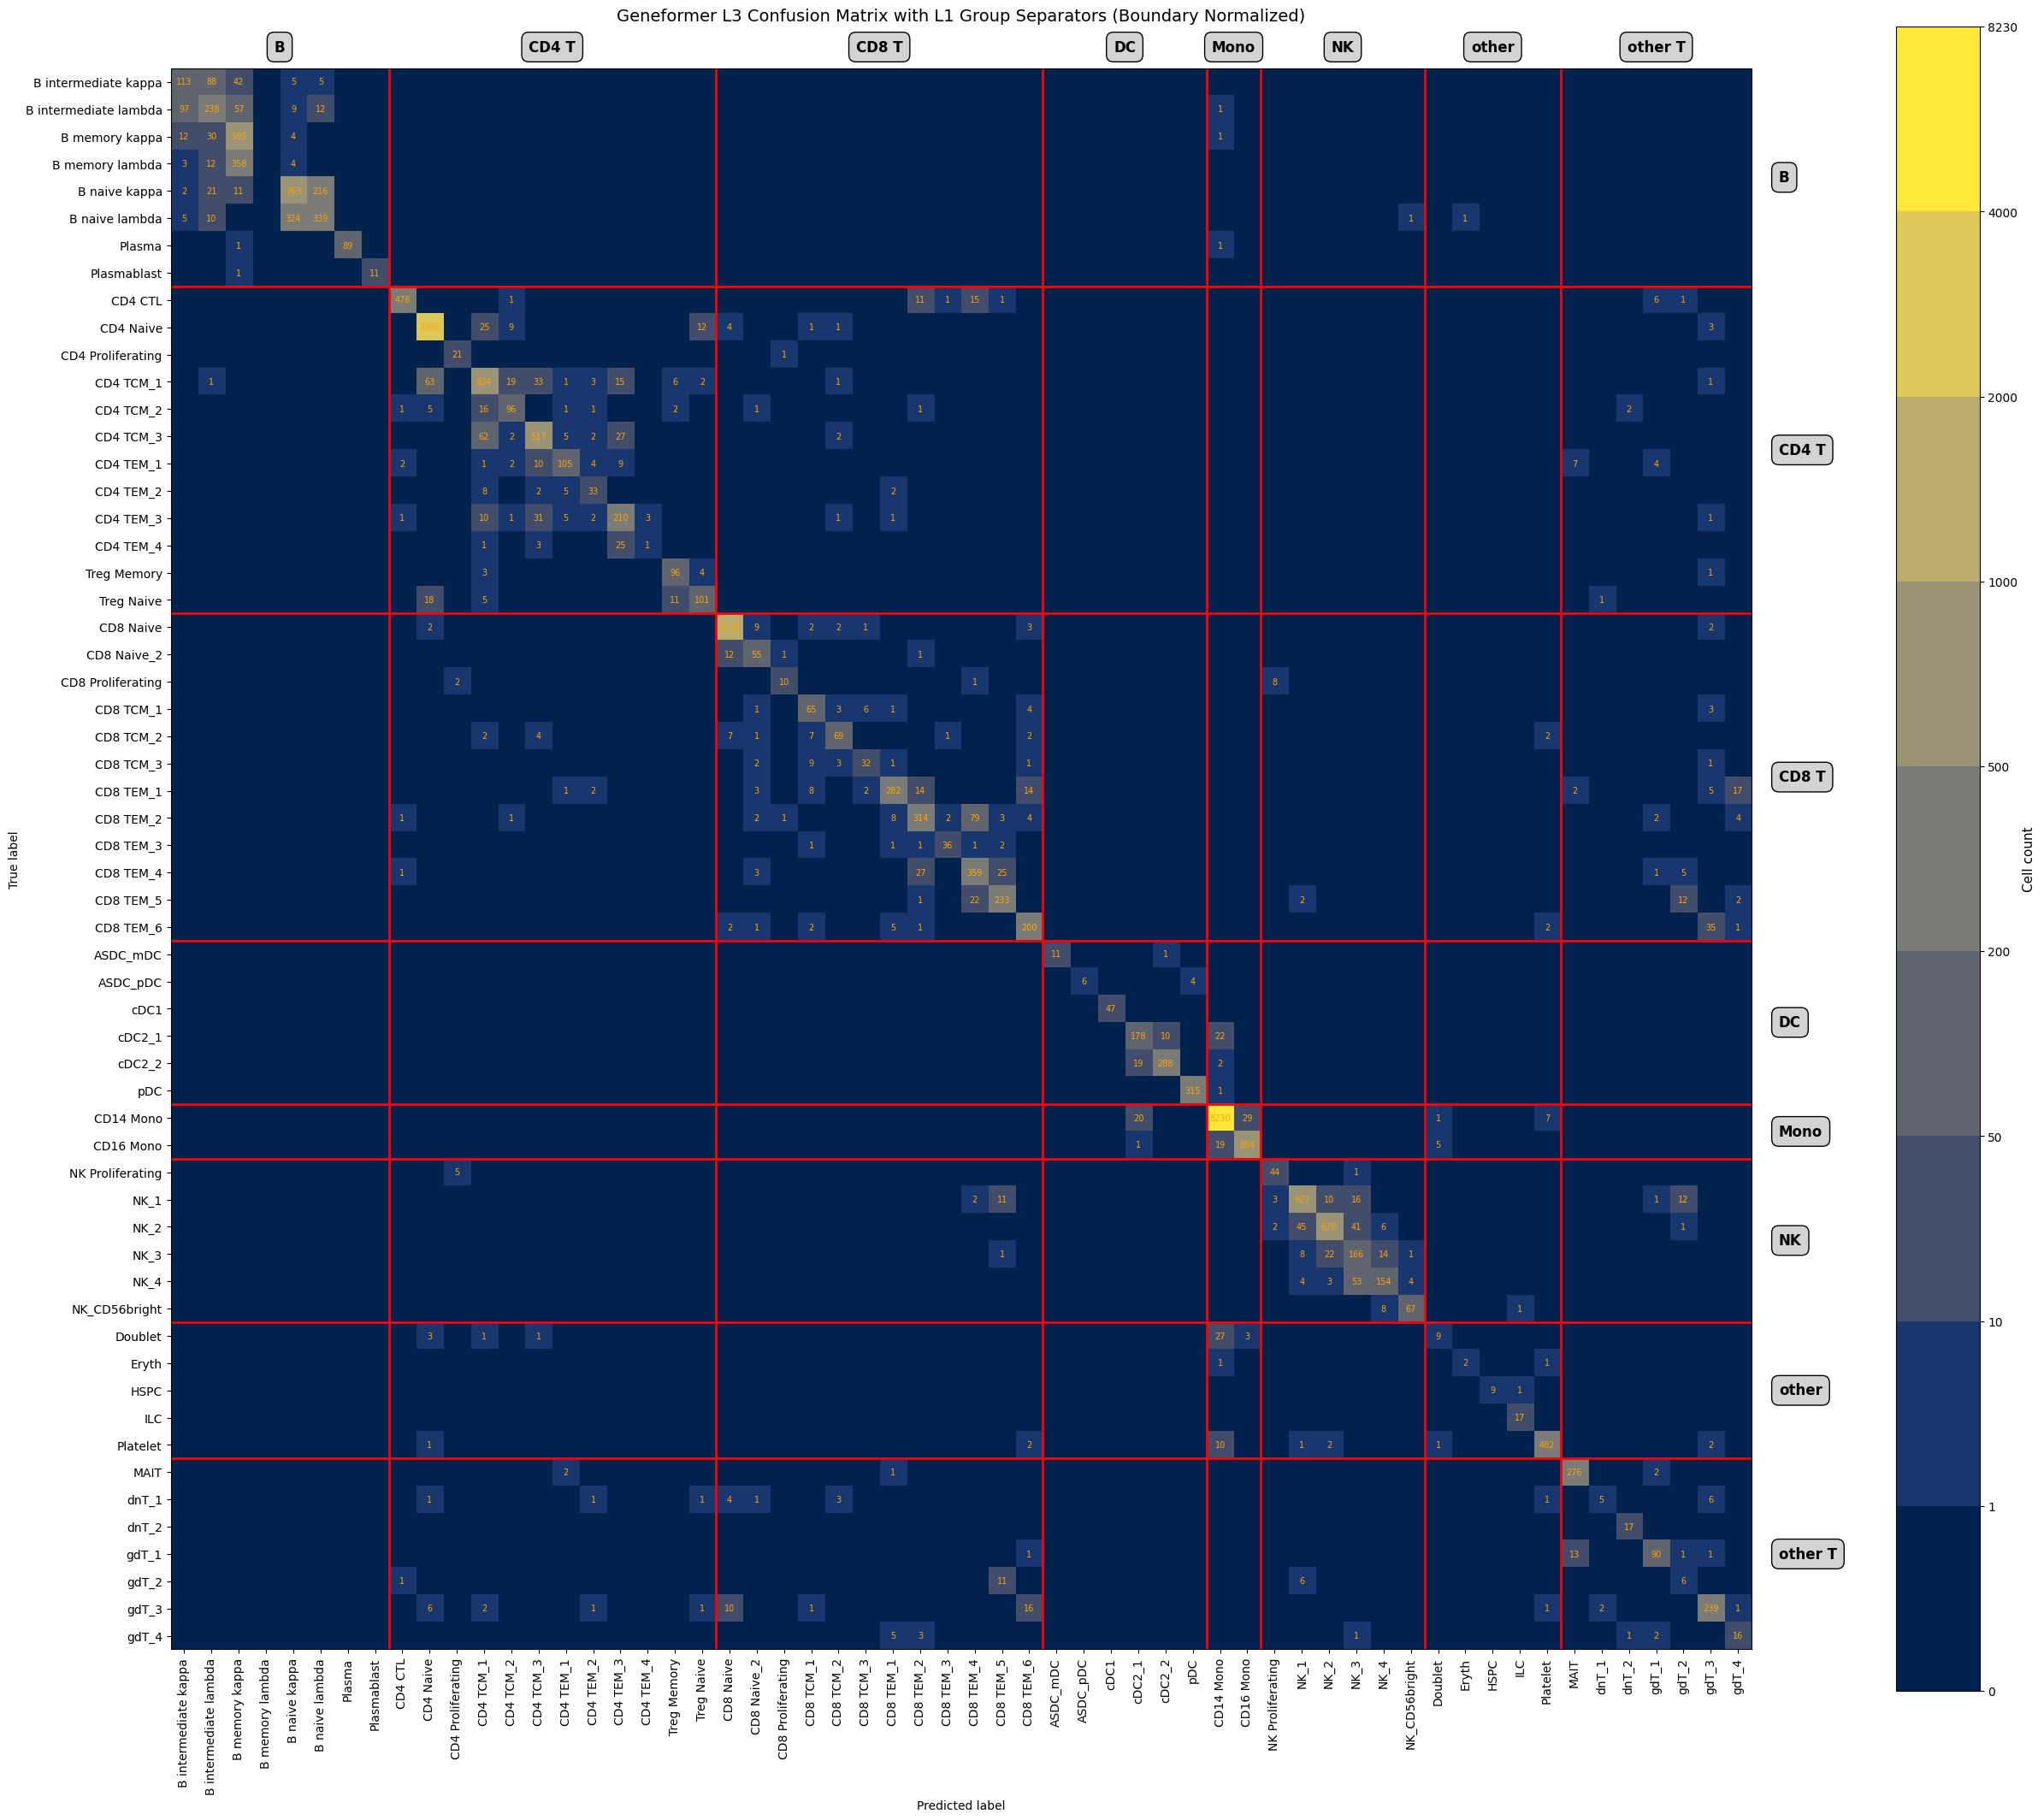

In [22]:
####################################################################################################
# Plot L3 Confusion Matrix with Boundary Normalization and L1 Group Annotations - Geneformer-V2-104M
####################################################################################################

from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.colors import BoundaryNorm

# Define boundaries appropriate for L3 dataset  
bounds = [0, 1, 10, 50, 200, 500, 1000, 2000, 4000, cm_df3.values.max()]
norm = BoundaryNorm(bounds, ncolors=256, clip=True)

fig, ax = plt.subplots(figsize=(24, 24))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_df3.values,
    display_labels=labels3
)
disp.plot(
    ax=ax,
    cmap="cividis",
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

# Apply normalization after plotting
im = disp.im_
im.set_norm(norm)

# Increase font size and hide zero-value annotations
for value, text in zip(cm_df3.values.ravel(), disp.text_.ravel()):
    if value == 0:
        text.set_text("")
        continue
    text.set_fontsize(7)
    text.set_color('orange')

# Add separators and L1 group annotations
l1_groups = []
current_l1 = None
start_idx = 0

for idx, l3 in enumerate(labels3):
    l1 = l3_to_l1.get(l3, 'Unknown')
    if l1 != current_l1:
        if current_l1 is not None:
            l1_groups.append((current_l1, start_idx, idx))
            # Draw separator line
            ax.axhline(y=idx - 0.5, color='red', linewidth=2)
            ax.axvline(x=idx - 0.5, color='red', linewidth=2)
        current_l1 = l1
        start_idx = idx

# Add the last group
if current_l1 is not None:
    l1_groups.append((current_l1, start_idx, len(labels3)))

# Add L1 group labels on the right side
for l1_name, start, end in l1_groups:
    mid_point = (start + end) / 2 - 0.5
    ax.text(len(labels3) + 0.5, mid_point, l1_name, 
            ha='left', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', edgecolor='black'))

# Add L1 group labels on the top (moved higher up and rotated)
for l1_name, start, end in l1_groups:
    mid_point = (start + end) / 2 - 0.5
    ax.text(mid_point, -1.0, l1_name, 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            rotation=0,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', edgecolor='black'))

# Add custom colorbar
cbar = fig.colorbar(im, ax=ax, ticks=bounds, fraction=0.046, pad=0.08)
cbar.ax.set_ylabel("Cell count", rotation=90, fontsize=11)

ax.set_title("Geneformer L3 Confusion Matrix with L1 Group Separators (Boundary Normalized)", fontsize=14, pad=40)
plt.tight_layout()
plt.show()

---
# __Plotting Test Metrics directly from `test_metrics` output of Geneneformer__
Geneformer already computes the test metrics which is stored as a dictionary output. This file can be used to get the evaluation metrics and confusion matrix instead of computing the evaluation metrics from the predictions dicionary. For the above example, computing metrics from predictions was preferred for L1-aware metric additions and to generate detailed classification report 

In [10]:
# Load the test evaluation metrics dictionary and print its keys
test_eval = pickle.load(open(TEST_EVAL_PATH, "rb"))
print(test_eval.keys())

dict_keys(['conf_matrix', 'macro_f1', 'acc', 'all_roc_metrics'])


In [11]:
# Inspect confusion matrix structure in the test metrics dictionary
conf_matrix = test_eval["conf_matrix"]
print("type:", type(conf_matrix))
print("keys:", conf_matrix.keys())
print("shape:", conf_matrix.shape)

type: <class 'pandas.core.frame.DataFrame'>
keys: Index(['Platelet', 'CD4 TCM_1', 'B intermediate lambda', 'CD8 TEM_2',
       'CD4 Proliferating', 'NK_4', 'dnT_2', 'CD4 TEM_1', 'B naive kappa',
       'HSPC', 'ASDC_mDC', 'B naive lambda', 'CD4 TEM_2', 'MAIT', 'Treg Naive',
       'CD4 TEM_4', 'CD4 TEM_3', 'CD8 TCM_3', 'pDC', 'NK_2', 'B memory lambda',
       'Doublet', 'gdT_1', 'CD8 Naive_2', 'ASDC_pDC', 'CD8 Naive',
       'NK Proliferating', 'CD8 TEM_3', 'NK_CD56bright', 'CD8 TEM_6', 'Eryth',
       'cDC2_2', 'CD8 TEM_4', 'NK_3', 'cDC1', 'B memory kappa', 'gdT_2',
       'CD14 Mono', 'NK_1', 'CD4 Naive', 'CD4 CTL', 'CD8 TEM_5',
       'CD8 Proliferating', 'cDC2_1', 'CD8 TCM_1', 'Plasmablast', 'CD16 Mono',
       'gdT_4', 'Treg Memory', 'CD4 TCM_2', 'dnT_1', 'gdT_3', 'ILC',
       'B intermediate kappa', 'CD8 TCM_2', 'Plasma', 'CD4 TCM_3',
       'CD8 TEM_1'],
      dtype='object')
shape: (58, 58)


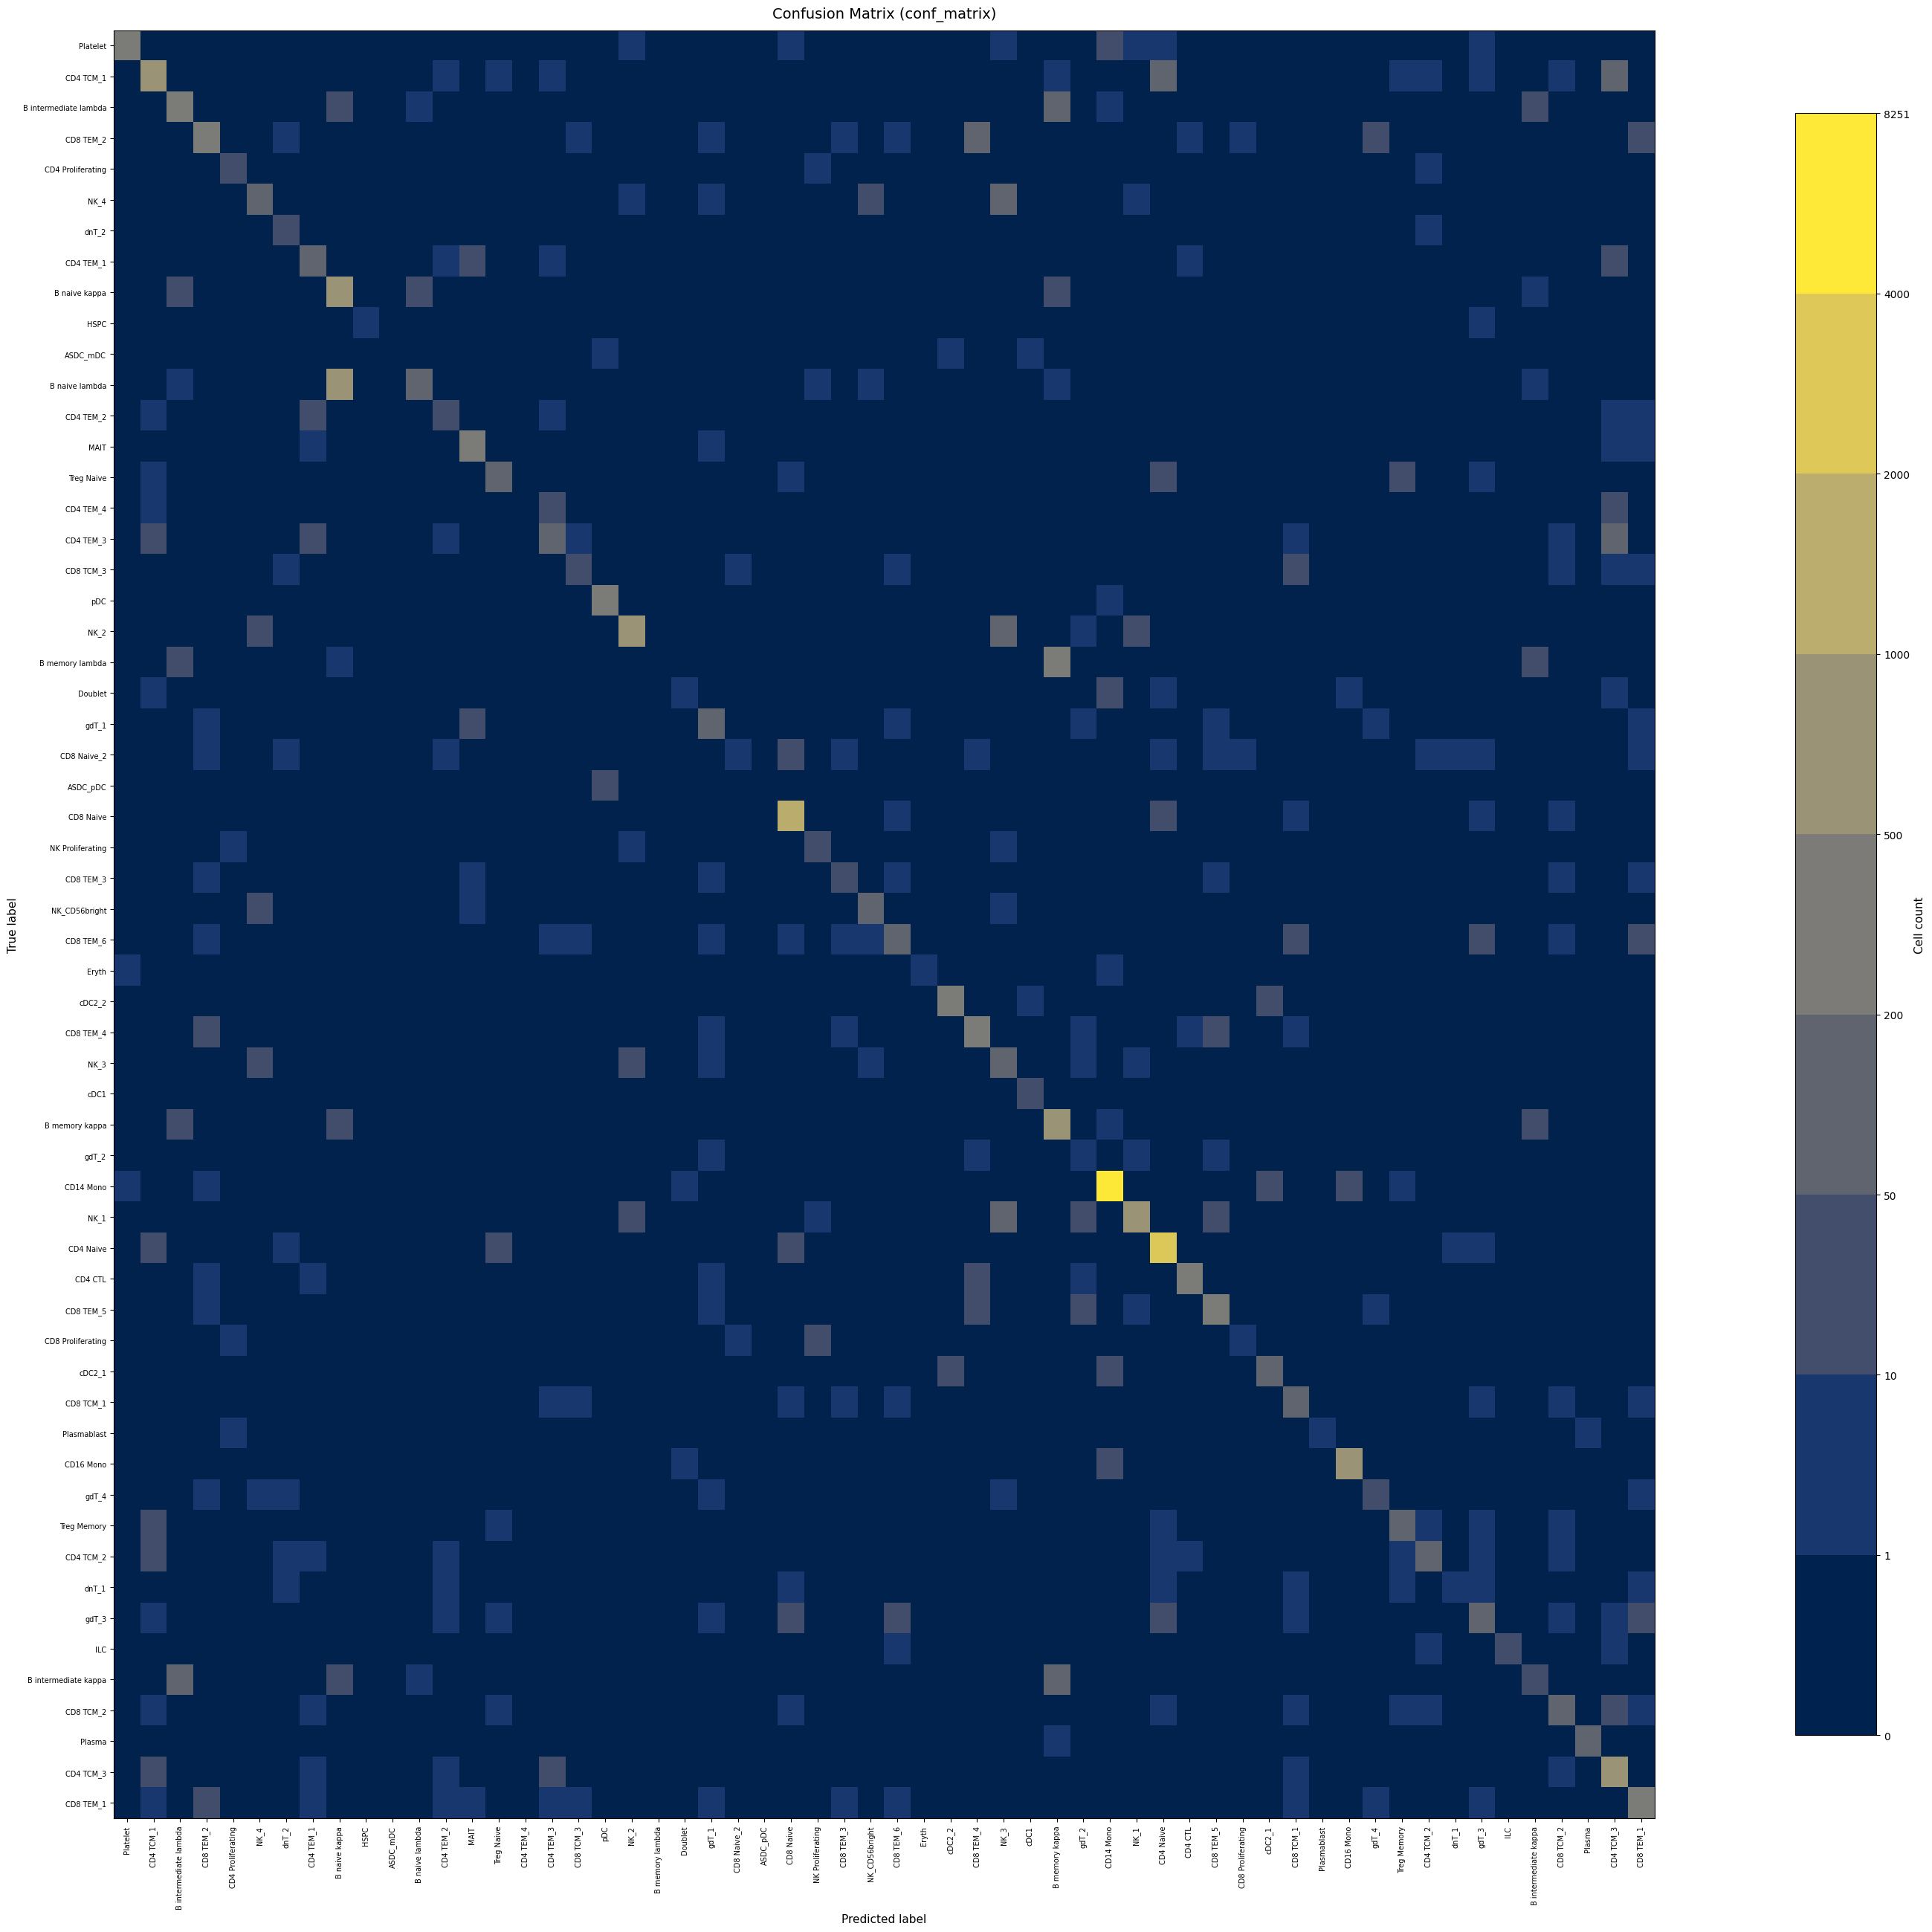

In [12]:
# Plot confusion matrix from test_eval['conf_matrix']
from matplotlib.colors import BoundaryNorm

# conf_matrix is a pandas DataFrame: rows = true labels, columns = predicted labels
cm_df = conf_matrix.copy()

# Optional: set to True for row-wise normalized values (proportion per true class)
NORMALIZE_ROWS = False
if NORMALIZE_ROWS:
    cm_plot = cm_df.div(cm_df.sum(axis=1).replace(0, 1), axis=0).values
    cbar_label = "Proportion"
    title_suffix = " (Row-normalized)"
else:
    cm_plot = cm_df.values
    cbar_label = "Cell count"
    title_suffix = ""

class_names = list(cm_df.index)
n_classes = len(class_names)
fig_size = max(10, min(28, n_classes * 0.45))

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

# Boundary-normalized colormap (same style as the pred-based plot above)
bounds = [0, 1, 10, 50, 200, 500, 1000, 2000, 4000, int(cm_plot.max())]
norm = BoundaryNorm(bounds, ncolors=256, clip=True)

im = ax.imshow(cm_plot, cmap="cividis", norm=norm, aspect="auto")

# Colorbar
cbar = fig.colorbar(im, ax=ax, ticks=bounds, fraction=0.046, pad=0.08)
cbar.ax.set_ylabel(cbar_label, rotation=90, fontsize=11)

# Axis ticks and labels
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)

ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title(f"Confusion Matrix (conf_matrix){title_suffix}", fontsize=14, pad=12)

plt.tight_layout()
plt.show()